# Module 5 Discussion Activity
- Author: Robert Feconda
- Email: rfecond1@jh.edu

## 1. Intelligent Smoke Detection
- An engineering team is building a probabilistic monitoring system for a smart building.
- There are four variables:
    - F = Fire
    - S = Smoke
    - A = Alarm
    - W = Sprinkler

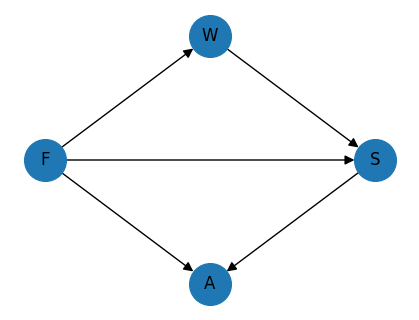

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

vertices = ['F', 'W', 'S', 'A']

edges = [
    ('F', 'W'),
    ('F', 'S'),
    ('F', 'A'),
    ('W', 'S'),
    ('S', 'A'),
]
dag = nx.DiGraph()
pos = {
    'F': (-1, 0),
    'W': (0, 1),
    'S': (1, 0),
    'A': (0, -1),
}

dag.add_nodes_from(vertices)
dag.add_edges_from(edges)
plt.figure(figsize=(4, 3))
nx.draw(
    dag,
    pos=pos,
    with_labels=True,
    node_size=900,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=14,
)
plt.show()

### Write the factorized joint distribution implied by this DAG.

- The factorized joint distribution can be obtained by factoring the loocal conditional distributions based on the following multiplicative summation formula:

$$
P(x_1,\dots,x_n)=\prod_{i=1}^{n} P(x_i \mid Parents(X_i))
$$


- factorized joint distibution:
$$
P(F,W,A,S) = P(F) \times P(A|F,S) \times P(S|F,W) \times P(W|F)
$$

### Using Bayes' rule conceptually, explain what it means to compute $P(F = True | A = True)$
- What belief is being updated?
    - If we were going forward, this would be a feedforward calculation. This if a form of exact inference in bayesian networks. We are computing the posterior of a query variable X given some e evidence. In this case, the $A=True$ is the evidence. $P(X \mid e)$.
    - In feedforward, We are computing the probability of $Effect | Cause$
    - HOWEVER, this definition is asking for the probability of F given A. In other words, estimate the probabilty of a parent given it's child.
    - This is called diagnostic reasoning -- computing posterior probabilities for query propositions given observed evidence.
    - If this were a temporal model, this would be a form of smoothing.


### State two conditional independence relationships implied by this graph

- Conditional independence means that two things become independent once you know some third piece of information. If Z fully explains the relationship between X and Y, then after conditioning on Z, X no longer depends on Y and the joint probability separates.
- The general defintion of conditional independence of two variables X and Y, given a third variable Z:  $$P(X, Y | Z) = P(X | Z)P(Y | Z) $$
    - This is true when $X⊥Y∣Z$
- Once F and S are known, W gives no extra info about A, and vice versa.
- So there is only 1 non-trivial conditional independence relationship in the DAG.
- Symmetry also gives $A⊥W∣{F,S}$ and  $W⊥A∣{F,S}$, so can consider that to be two.

### Assume all variables are binary:
- How many parameters are needed for the full joint distribution?
    - For a full joint distribution you need $2^4 - 1 = 15$ independent parameters
- How many are needed under the Bayesian network factorization?
    - 1 for F, 2 for W, 4 for S, and 4 for A gives 11 independent parameters.
- What is the computational implication?
    - Bayesian network factorization scales better than trying to store the full conditional probability table. Doing so for large size sets is intractable. 

## 2. VE vs JT (Variable Elimination vs Junction Tree)

- Given a small bayesian network (sprinkler model) with binary variables:

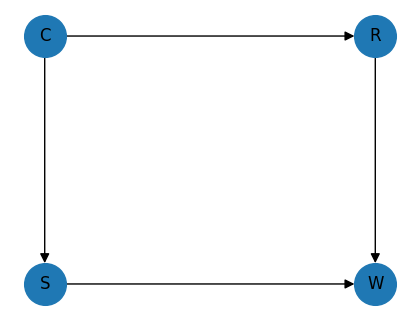

In [15]:
import matplotlib.pyplot as plt
import networkx as nx

vertices = ['C', 'R', 'S', 'W']

edges = [
    ('C', 'R'),
    ('C', 'S'),
    ('R', 'W'),
    ('S', 'W'),
]
bays_net = nx.DiGraph()
pos = {
    'C': (-1, 1),
    'R': (1, 1),
    'S': (-1, -1),
    'W': (1, -1),
}

bays_net.add_nodes_from(vertices)
bays_net.add_edges_from(edges)
plt.figure(figsize=(4, 3))
nx.draw(
    bays_net,
    pos=pos,
    with_labels=True,
    node_size=900,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=14,
)
plt.show()

- Query of interest is: $P(R | W = true)$

  ~~~Python
  # Variable Elimination
  def variable_elimination(BN, query, evidence, order):     
    factors = initialize_factors(BN)
    factors = restrict_evidence(factors, evidence)

    for var in order:
      related = [f for f in factors if var in f.scope]
      product = multiply(related)
      summed = sum_out(product, var)
      factors = [f for f in factors if var not in f.scope] + [summed]

    result = normalize(multiply(factors))
   return marginalize(result, query)
   ~~~

 ~~~python
  # Junction Tree Inference
  def junction_tree_inference(BN, query, evidence):
    JT = build_junction_tree(BN)
    assign_evidence(JT, evidence)
    calibrate(JT)  # inward + outward message passing
    clique = find_clique_containing(JT, query)
    return marginalize(clique.belief, query)
~~~

## Answer the following:
1. Explain how each algorithm computes the posterior.
    - VE builds factors from CPTs, conditions on the evidence, and then eliminates non-query variables by summing them out in some order. The remaining factors over the query variable is normalized to get the posterior (made sure to sum to 1).
    - JT compiles the bayesian net into a clique tree, initializes them and assigns the evidence, runs message passing until calibrated, and then reads marginals from any clique containing the query variable and normalizes.
        - Each edge may store the setpset and the messages
        - Cliques overlap on shared variables
        - Junction tree is built with running intersection property in mind -- if a variable appears in multiple, all those cliques mut be connected
        - In the message passing, eveything not in the sepset is sum'd out.

2. Identify where summation occurs in each method.
    - VE: during elimination of each hidden variable. It sums over that variable in the product of relevant factors.
    - JT: In message computation from one clique to another. It marginalizes variables not in the separator set.

3. Identify where multiplication occurs in each method.
    - VE: Multiply factors that share the variable currently currently being eliminated
    - JT: Multiply local clique potential with incoming messages

4. Explain why Variable Elimination must be repeated for each new query, while Junction Tree does not.
    - VE is query specific computation graph. Eliminated variables and intermediate factors are rebuilt for each query.
    - JT is global computation. Most cost is paid up front during the compilation and calibration. Many queries can be answered by local reads and message updates without rebuilding from scratch.

5. Compare the computational trade-offs between the two approaches.
    - VE: lower upfront and good for few queries but repeats work across multiple queries of similar semantics.
    - JT: high upfront cost but efficient for many queries and evidence updates

6. Based on your understanding, describe one scenario where VE would be preferable, and one where JT would be preferable.
    - Given a medical scenario, if we are just needing to make a single inference about a patient given some evidence, using a VE would be best. We won't use it as a continual model for different people.
    - For a disease over a more general population, we would likely want to use a JT so we can do multiple quries over the varying population.

## 3. Estimating a Posterior by Sampling

We estimate $P(D=\text{true} \mid T=\text{positive}, S=\text{true})$ by **rejection sampling** using AIMA's `rejection_sampling` function.


In [16]:
# Fixing imports so I can use the code from AIMA
import sys
from pathlib import Path

aima_path = (Path.cwd().resolve().parent / 'aima')
if str(aima_path) not in sys.path:
    sys.path.append(str(aima_path))

from probability import BayesNet, rejection_sampling, enumeration_ask

# Build the Bayesian network structure: Disease -> Test and Disease -> Symptom.
# Variables are boolean in this implementation:
# - Disease=True means disease present
# - Test=True means test is positive
# - Symptom=True means symptom is present
disease_bn = BayesNet([
    ('Disease', '', 0.05),
    ('Test', 'Disease', {True: 0.9, False: 0.1}),
    ('Symptom', 'Disease', {True: 0.8, False: 0.2}),
])

# Evidence for the query P(Disease=True | Test=True, Symptom=True).
evidence = {'Test': True, 'Symptom': True}
query_var = 'Disease'
sample_sizes = [100, 1_000, 10_000] 

print('Rejection sampling estimates for P(Disease=True | Test=True, Symptom=True):')
for n in sample_sizes:
    # Rejection sampling process:
    # 1) sample full assignments from the prior
    # 2) reject assignments inconsistent with evidence
    # 3) estimate posterior from accepted assignments
    posterior = rejection_sampling(query_var, evidence, disease_bn, N=n)
    print(f"N={n:>6}: P(D=True)={posterior[True]:.4f}, P(D=False)={posterior[False]:.4f}")

# Quick computation of the exact inference for comparison
exact = enumeration_ask(query_var, evidence, disease_bn)
print(f"Exact  : P(D=True)={exact[True]:.4f}, P(D=False)={exact[False]:.4f}")


Rejection sampling estimates for P(Disease=True | Test=True, Symptom=True):
N=   100: P(D=True)=0.6667, P(D=False)=0.3333
N=  1000: P(D=True)=0.6415, P(D=False)=0.3585
N= 10000: P(D=True)=0.6751, P(D=False)=0.3249
Exact  : P(D=True)=0.6545, P(D=False)=0.3455


### Brief Explanation

1. **Why sampling is approximate inference**  
Sampling uses a finite random set of generated worlds instead of exact summation over all worlds. Because the sample is finite and random, the result is an estimate.

2. **What happens to variance as sample size increases**  
As sample size grows, estimate variance decreases and the posterior estimate becomes more stable.

3. **Why this scales better than exact inference in large networks**  
Exact inference can become expensive due to large intermediate factors. Sampling avoids full symbolic factor operations and often gives useful approximations with bounded compute.

4. **One limitation of rejection sampling**  
When evidence is rare, most generated samples are rejected, so efficiency drops and many more samples are needed. The book also notes that this is a serious issue with float point arithmetic in some computations.
